
# 뉴스 유목민 지수(NNI) v2 — 통계적 타당성 + 서비스 활용을 고려한 개선판

## 이 노트북에서 무엇이 달라졌나 (데모 코드 대비)

**1) NNI 계산 로직 자체를 다시 설계**
- 기존: 주 이용경로(Q84) 응답 하나에만 의존해 '이탈도(D)'를 계산 → Q84의 무응답 코드(9998)가
  최대 이탈도로 잘못 합산되는 버그가 있었음, Q84가 결측이면 지표 자체가 깨짐.
- 개선: 응답자가 **실제로 이용한 모든 채널의 빈도**를 이용해 이탈도를 '빈도 가중 평균'으로 계산.
  → 결측/무응답에 안전하고, 통계적으로도 더 안정적인 연속형 지표가 됨.

**2) 가중치(α, β)를 임의의 0.5/0.5가 아니라 데이터에서 추정**
- H_norm(분산도)과 D_weighted(이탈도)를 표준화한 뒤 PCA 1주성분의 적재값(loading)으로
  가중치를 도출 → "왜 0.5:0.5인가?"에 대한 근거를 지표 자체가 제공하도록 함.

**3) 구성 타당도(construct validity) 검증 절차 추가**
- NNI를 만들 때 쓰지 않은 변수들(언론 신뢰도, 출처별 신뢰도, 언론사 인지도, 유료 이용 의향 등)과
  상관관계를 확인 → "NNI가 실제로 무엇을 측정하는지" 통계적으로 뒷받침.

**4) 인구통계는 군집화 입력이 아니라 '프로파일링' 변수로만 사용**
- 나이만 쓰는 대신, 성별·학력까지 포함해 군집을 사후적으로 설명(cross-tab).
- 인구통계를 군집화 피처에 넣지 않는 이유: 넣으면 "미디어 이용 패턴"이 아니라
  "인구통계 분포"로 군집이 갈릴 위험이 있음 (예: 그냥 연령별로만 나뉘어 버릴 수 있음).

**5) 서비스 활용도를 고려한 구조**
- 학습된 scaler/kmeans를 재사용 가능한 형태(joblib)로 저장.
- 신규 이용자의 응답(짧은 설문 몇 문항)만으로 NNI 점수·백분위·유형을 즉시 계산해주는
  `score_new_user()` 함수 제공 → 실제 웹/앱 서비스 백엔드에 바로 이식 가능한 구조.

---
전제: 파일 경로는 사용자 환경에 맞게 수정. 2025 언론수용자 조사 최종데이터(6,000명, 223문항) 기준.


In [3]:

# =========================================================
# 0. 라이브러리 & 옵션
# =========================================================
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

import joblib  # 학습된 전처리기/모델을 파일로 저장해 서비스에서 재사용하기 위함
import os

pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 240)

# 한글 폰트 설정 (환경에 맞게 수정: Windows는 'Malgun Gothic', Mac은 'AppleGothic')
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline


In [6]:

# =========================================================
# 1. 데이터 불러오기
# =========================================================
# 사용자 환경에 맞게 경로만 바꾸면 됨 (같은 폴더에 두면 파일명만 남겨도 됨)
DATA_PATH = "2. 2025 언론수용자 조사_최종데이터.xlsx"

df = pd.read_excel(DATA_PATH).copy()
print('원본 데이터 shape:', df.shape)

# 조사 설계가중치(WT): 이 조사는 인구 구조에 맞춰 가중치를 부여한 확률표본 조사이므로,
# "군집별 규모가 전체 인구에서 차지하는 비중"처럼 모집단을 대표해야 하는 통계에는
# 반드시 WT를 곱해 가중 평균/가중 비율을 내야 함 (그렇지 않으면 표본 구성 편향이 그대로 남음).
# 군집화(KMeans) 자체는 개별 응답자 단위 패턴을 찾는 것이므로 WT를 곱하지 않고 원자료로 수행.
assert 'WT' in df.columns, "설계가중치 WT 컬럼이 없습니다. 원자료 구조를 확인하세요."


원본 데이터 shape: (6000, 223)



## 2. 뉴스 채널 빈도 변수 구성 — "뉴스 특화" 문항만 사용

설문지(코드북) 확인 결과, 이 조사는 채널마다
"그냥 그 채널을 이용했는가"(예: Q50 온라인 동영상 플랫폼 이용 여부)와
"그 채널에서 **뉴스/시사 콘텐츠**를 이용했는가"(예: Q53 → Q54 뉴스/시사 콘텐츠 이용 빈도)를
따로 물어봄. NNI는 '뉴스 유목민'을 재는 지표이므로, 반드시 후자(뉴스 특화 빈도)만 사용해야 함.

| key | 실제 문항 | 의미 | 이탈도 tier |
|---|---|---|---|
| newspaper | Q2A_1 | 종이신문(PDF판 포함) 평일 이용일수 | 0 (기관/원본) |
| tv        | Q14A_1 | TV 뉴스/시사 프로그램 평일 시청일수 | 0 |
| radio     | Q21A_1 | 라디오 뉴스/시사 프로그램 평일 청취일수 | 0 |
| magazine  | Q9A_1  | 뉴스/시사 잡지 평일 이용일수 | 0 |
| portal    | max(Q32A_1, Q32A_2) | 포털/검색엔진 통한 뉴스 평일 이용일수(모바일/PC 중 더 큰 값) | 1 |
| podcast   | Q79A_1 | 뉴스/시사 팟캐스트 평일 이용일수 | 1 |
| messenger | Q40A_1 | 메신저를 통한 뉴스 평일 이용일수 | 2 |
| sns       | Q47A_1 | SNS를 통한 뉴스 평일 이용일수 | 2 |
| video     | Q54A_1 | 온라인 동영상 플랫폼 뉴스/시사 콘텐츠 평일 이용일수 | 2 |
| shortform | Q62A_1 | 뉴스/시사 숏폼 평일 이용일수 | 2 |
| genai     | Q74A_1 | 생성형 AI 서비스 통한 뉴스/시사 콘텐츠 평일 이용일수 | 2 |

**tier 정의(이탈도 개념)**
- tier 0: 언론사가 직접 발행/방영하거나, 언론사 브랜드가 그대로 유지되는 경로(원본에 가까움)
- tier 1: 언론사 브랜드는 남아있지만 포털/앱 등 제3자가 배열·큐레이션에 개입(반쯤 이탈)
- tier 2: 원 저작자(언론사) 표시가 흐려지고 알고리즘/지인 네트워크가 소비를 주도(완전 이탈)

Q84(주 이용경로 응답, 18개 보기)는 아래에서 보듯 **주 지표 계산에는 쓰지 않고,
검증/설명용으로만** 사용함(13절).


In [7]:

# =========================================================
# 2-1. 채널 빈도 변수 만들기 (결측 = 그 채널을 아예 이용 안 한 것 -> 0으로 처리)
# =========================================================
# 설문 스킵 로직상, 해당 채널을 애초에 이용하지 않은 사람은 하위 빈도 문항이 NaN으로 남음.
# 즉 NaN == "이용 안함(0일)" 이 맞는 해석임 (실제 무응답이 아니라 문항 자체가 안 물어봄).

raw_cols = ['Q2A_1', 'Q14A_1', 'Q21A_1', 'Q9A_1',
            'Q32A_1', 'Q32A_2', 'Q79A_1',
            'Q40A_1', 'Q47A_1', 'Q54A_1', 'Q62A_1', 'Q74A_1']
for c in raw_cols:
    df[c] = df[c].fillna(0)

# channel_specs: 채널별 (컬럼 계산식, tier, 한글 라벨)을 한 곳에 모아 관리
# -> 이후 H_norm/D_weighted 계산, 시각화, 서비스 함수에서 전부 이 딕셔너리 하나만 참조하면 되므로
#    나중에 채널을 추가/제외하기가 쉬움 (유지보수성 확보)
df['portal_freq'] = df[['Q32A_1', 'Q32A_2']].max(axis=1)

channel_specs = {
    'newspaper': {'col': 'Q2A_1',      'tier': 0, 'label': '종이신문'},
    'tv':        {'col': 'Q14A_1',     'tier': 0, 'label': 'TV뉴스'},
    'radio':     {'col': 'Q21A_1',     'tier': 0, 'label': '라디오뉴스'},
    'magazine':  {'col': 'Q9A_1',      'tier': 0, 'label': '시사잡지'},
    'portal':    {'col': 'portal_freq','tier': 1, 'label': '포털뉴스'},
    'podcast':   {'col': 'Q79A_1',     'tier': 1, 'label': '팟캐스트뉴스'},
    'messenger': {'col': 'Q40A_1',     'tier': 2, 'label': '메신저뉴스'},
    'sns':       {'col': 'Q47A_1',     'tier': 2, 'label': 'SNS뉴스'},
    'video':     {'col': 'Q54A_1',     'tier': 2, 'label': '온라인동영상뉴스'},
    'shortform': {'col': 'Q62A_1',     'tier': 2, 'label': '숏폼뉴스'},
    'genai':     {'col': 'Q74A_1',     'tier': 2, 'label': '생성형AI뉴스'},
}

channel_cols  = [spec['col']  for spec in channel_specs.values()]
channel_tiers = np.array([spec['tier'] for spec in channel_specs.values()], dtype=float)

print('사용 채널 수:', len(channel_specs))
print(df[channel_cols].describe().round(2).T)


사용 채널 수: 11
              count  mean   std  min  25%  50%  75%  max
Q2A_1        6000.0  0.26  1.01  0.0  0.0  0.0  0.0  5.0
Q14A_1       6000.0  3.33  1.93  0.0  2.0  4.0  5.0  5.0
Q21A_1       6000.0  0.26  0.98  0.0  0.0  0.0  0.0  5.0
Q9A_1        6000.0  0.05  0.44  0.0  0.0  0.0  0.0  5.0
portal_freq  6000.0  2.32  2.03  0.0  0.0  2.0  5.0  5.0
Q79A_1       6000.0  0.03  0.34  0.0  0.0  0.0  0.0  5.0
Q40A_1       6000.0  0.37  1.11  0.0  0.0  0.0  0.0  5.0
Q47A_1       6000.0  0.20  0.79  0.0  0.0  0.0  0.0  5.0
Q54A_1       6000.0  0.87  1.62  0.0  0.0  0.0  1.0  5.0
Q62A_1       6000.0  0.64  1.40  0.0  0.0  0.0  0.0  5.0
Q74A_1       6000.0  0.04  0.35  0.0  0.0  0.0  0.0  5.0



## 3. 뉴스 유목민 지수(NNI) 재정의

### 3-1. H_norm (채널 분산도) — 기존과 동일한 섀넌 엔트로피, 채널 셋만 교체
### 3-2. D_weighted (이탈도) — **핵심 개선점**

기존 D는 "주 이용경로 1개"의 tier 값을 그대로 썼음 (범주형 1문항 의존).
개선된 D_weighted는 실제 이용한 **모든 채널의 빈도로 가중평균**한 이탈도:

D_weighted = ( Σ(빈도_i × tier_i) / Σ빈도_i ) / 2   (2로 나누는 것은 tier 최댓값 2로 0~1 정규화)

장점:
- 한 문항(Q84)의 결측/무응답에 지표 전체가 좌우되지 않음(강건성).
- "가끔 포털도 보지만 주로 유튜브로 본다" 같은 **정도의 차이**를 반영 가능(기존은 0 아니면 1이었음).
- H_norm과 계산에 쓰인 원천 데이터(채널별 빈도)가 동일해, 두 축이 "같은 언어"로 말해서
  이후 하나의 지수로 합칠 때 이론적으로 더 타당함.


In [8]:

# =========================================================
# 3-1. H_norm : 채널 이용의 분산도(엔트로피)
# =========================================================
def shannon_entropy_from_row(values):
    # 비율분포의 섀넌 엔트로피. 한 채널만 몰아서 쓰면 0, 여러 채널에 고르게 분산될수록 커짐.
    arr = np.asarray(values, dtype=float)
    total = arr.sum()
    if total <= 0:
        return np.nan  # 이번 주 뉴스 이용 자체가 없는 경우 -> 분산도 정의 불가 (아래에서 별도 처리)
    p = arr[arr > 0] / total
    return -(p * np.log2(p)).sum()

H_max = np.log2(len(channel_cols))  # 채널 수가 늘었으므로 log2(11)로 자동 반영됨

df['H'] = df[channel_cols].apply(lambda row: shannon_entropy_from_row(row.values), axis=1)
df['H_norm'] = df['H'] / H_max

# =========================================================
# 3-2. D_weighted : 빈도 가중 이탈도
# =========================================================
freq_matrix = df[channel_cols].to_numpy(dtype=float)          # (N, 11)
row_total   = freq_matrix.sum(axis=1)                         # 사람별 총 채널 이용일수 합

with np.errstate(invalid='ignore', divide='ignore'):
    weighted_tier = (freq_matrix * channel_tiers).sum(axis=1) / row_total

df['D_weighted'] = np.where(row_total > 0, weighted_tier / 2.0, np.nan)  # tier 최댓값 2로 정규화 -> [0,1]

# =========================================================
# 이번 주 뉴스 채널을 하나도 이용하지 않은 사람(= '뉴스 비활성' 상태)
# -> 유목민(H, D 모두 정의되는 소비자)과는 다른 집단이므로 별도 플래그만 남기고,
#   NNI 계산 대상에서는 제외(추후 별도 세그먼트로 설명하는 것이 더 정직한 해석)
# =========================================================
df['news_inactive'] = row_total == 0
print('이번 주 뉴스 채널 이용이 전혀 없는 응답자 수:', df['news_inactive'].sum(),
      '(', round(df['news_inactive'].mean()*100, 1), '%)')

print()
print('[H_norm / D_weighted 기초통계 (뉴스 이용자만)]')
print(df.loc[~df['news_inactive'], ['H_norm', 'D_weighted']].describe().round(3))


이번 주 뉴스 채널 이용이 전혀 없는 응답자 수: 303 ( 5.1 %)

[H_norm / D_weighted 기초통계 (뉴스 이용자만)]
         H_norm  D_weighted
count  5697.000    5697.000
mean      0.286       0.307
std       0.237       0.264
min      -0.000       0.000
25%       0.000       0.000
50%       0.286       0.250
75%       0.458       0.500
max       0.993       1.000



### 3-3. NNI 결합 가중치(α, β)를 데이터로부터 추정

"H_norm과 D_weighted를 왜 5:5로 섞는가?"에 답하기 위해, 두 변수를 표준화한 뒤
PCA 1주성분(가장 많은 공통분산을 설명하는 방향)의 적재값을 가중치로 사용한다.

- 두 변수가 실제로 강하게 같이 움직인다면 PC1 설명분산비율이 높고, 가중치도 안정적으로 나옴.
- 만약 설명분산비율이 낮다면(예: 50% 미만) 두 변수가 서로 다른 정보를 담고 있다는 뜻이므로,
  단일 지수로 합치는 것 자체를 재고해야 한다는 신호로 해석하고 그 사실을 그대로 보고한다.


In [9]:

# =========================================================
# 3-3. PCA 기반 데이터 주도 가중치(alpha, beta) 산출
# =========================================================
valid = ~df['news_inactive']
hd = df.loc[valid, ['H_norm', 'D_weighted']].dropna()

hd_scaler = StandardScaler()
hd_scaled = hd_scaler.fit_transform(hd)

pca_hd = PCA(n_components=2, random_state=42).fit(hd_scaled)
loadings = pca_hd.components_[0]          # [H_norm 적재값, D_weighted 적재값]
explained_ratio = pca_hd.explained_variance_ratio_[0]

# 부호를 "값이 클수록 더 유목민"이라는 방향으로 통일 (PCA는 부호가 임의로 정해짐)
if loadings.sum() < 0:
    loadings = -loadings

alpha, beta = loadings / loadings.sum()   # 합이 1이 되도록 정규화 -> 그대로 가중치로 사용

corr_hd, p_hd = pearsonr(hd['H_norm'], hd['D_weighted'])

print('H_norm과 D_weighted의 상관계수 r =', round(corr_hd, 3), '(p =', round(p_hd, 4), ')')
print('PC1 설명분산비율 =', round(explained_ratio*100, 1), '%')
print('데이터 기반 가중치 -> alpha(H_norm) =', round(alpha, 3), ', beta(D_weighted) =', round(beta, 3))

if explained_ratio < 0.5:
    print()
    print('[주의] PC1 설명분산비율이 50% 미만입니다. H_norm과 D_weighted가 서로 다른 정보를 담고 있을')
    print('가능성이 큽니다. 단일 NNI 점수 외에 두 축을 따로 보고하는 것을 권장합니다.')


H_norm과 D_weighted의 상관계수 r = 0.656 (p = 0.0 )
PC1 설명분산비율 = 82.8 %
데이터 기반 가중치 -> alpha(H_norm) = 0.5 , beta(D_weighted) = 0.5


In [10]:

# =========================================================
# 3-4. 최종 NNI 계산 (0~1 스케일 유지, 해석 가능하도록)
# =========================================================
# 주의: 위에서 구한 alpha/beta는 '표준화된' 변수로 추정한 결합비율이지만,
# 실제 지수는 사람들이 이해하기 쉬운 0~1 스케일(H_norm, D_weighted 원래 값)에 그대로 적용한다.
# -> 서비스 화면에 "0~100점" 형태로 보여주기 위함 (표준화 점수는 일반 사용자에게 직관적이지 않음)

df['NNI'] = np.where(
    df['news_inactive'],
    np.nan,
    alpha * df['H_norm'] + beta * df['D_weighted']
)

# 사용자에게 보여줄 백분위 점수 (예: "당신은 상위 12%의 뉴스 유목민입니다")
df['NNI_percentile'] = df['NNI'].rank(pct=True) * 100

print(df[['H_norm', 'D_weighted', 'NNI', 'NNI_percentile']].describe().round(3))


         H_norm  D_weighted       NNI  NNI_percentile
count  5697.000    5697.000  5697.000        5697.000
mean      0.286       0.307     0.297          50.009
std       0.237       0.264     0.228          28.601
min      -0.000       0.000     0.000          13.060
25%       0.000       0.000     0.000          13.060
50%       0.286       0.250     0.270          50.105
75%       0.458       0.500     0.479          74.162
max       0.993       1.000     0.843         100.000



## 4. NNI의 구성 타당도(construct validity) 점검

지표를 "만들었다"는 것과 "그 지표가 실제로 의미가 있다"는 것은 다른 문제.
NNI 계산에 **전혀 쓰지 않은** 변수들과의 상관관계를 확인해서, 이 지수가 이론적으로
기대되는 방향으로 다른 지표들과 연결되는지 검증한다.

| 검증 변수 | 기대 방향 | 이론적 근거 |
|---|---|---|
| Q87_1 (뉴스 전반 신뢰도) | NNI 상승 시 신뢰도 하락 또는 무관 | 맥락 없는 소비는 전반적 신뢰 저하와 연결된다는 문제의식 |
| Q88_1~3 평균 (SNS·1인크리에이터·포털 추천 뉴스 신뢰도) | NNI 상승 시 신뢰도 상승 | 유목민일수록 알고리즘/지인 추천 출처에 상대적으로 더 의존 |
| Q93 (언론사 인지 여부) | NNI 상승 시 인지도 하락 | "어느 언론사 기사인지 모른 채" 소비하는 정도와 직결 |
| Q97_1 (온라인 뉴스 유료 이용 의향) | NNI 상승 시 의향 하락 | 특정 언론사에 대한 애착이 옅을수록 유료 구독 유인이 작음 |
| DQ3 (연령) | NNI 상승 시 연령 하락 | 청년층의 플랫폼 중심 소비 경향에 대한 선행 문제의식과 일치하는지 확인 |


In [11]:

# =========================================================
# 4. 구성 타당도 검증용 변수 준비 + 상관관계 표
# =========================================================
df['trust_curated_avg'] = df[['Q88_1', 'Q88_2', 'Q88_3']].mean(axis=1)  # 출처별(알고리즘/지인) 신뢰도 평균
df['q97_1_yes'] = (df['Q97_1'] == 1).astype(int)                        # 유료 이용 의향(있음=1)
df['q93_known'] = df['Q93']  # 1(전혀모름)~5(매우잘앎). 결측은 문26에서 인터넷뉴스 자체를 안 본 경우

validity_checks = {
    'Q87_1 (뉴스 전반 신뢰도)':            ('Q87_1', '음(-) 또는 무관'),
    'Q88 평균 (알고리즘/지인 추천 신뢰도)': ('trust_curated_avg', '양(+)'),
    'Q93 (언론사 인지 여부)':              ('q93_known', '음(-)'),
    'Q97_1 (유료 이용 의향, Yes=1)':       ('q97_1_yes', '음(-)'),
    'DQ3 (연령)':                        ('DQ3', '음(-)'),
}

rows = []
nni_valid = df['NNI'].notna()
for label, (col, expected) in validity_checks.items():
    sub = df.loc[nni_valid & df[col].notna(), ['NNI', col]]
    r, p = pearsonr(sub['NNI'], sub[col])
    rows.append({'검증 변수': label, 'n': len(sub), '상관계수 r': round(r, 3),
                 'p-value': round(p, 4), '기대 방향': expected})

validity_table = pd.DataFrame(rows)
print(validity_table.to_string(index=False))
print()
print('해석: 위 상관관계들이 기대 방향과 일치할수록 NNI가 이론이 예측하는 현상(맥락 없는 뉴스')
print('소비, 언론사 브랜드 인지 저하, 낮은 지불 유인 등)을 실제로 포착하고 있다는 증거가 된다.')
print('방향이 어긋나는 항목이 있다면 NNI의 정의(채널 tier 구간 설정 등)를 재검토해야 한다.')


                  검증 변수    n  상관계수 r  p-value      기대 방향
      Q87_1 (뉴스 전반 신뢰도) 5697  -0.017   0.1962 음(-) 또는 무관
Q88 평균 (알고리즘/지인 추천 신뢰도) 5697   0.211   0.0000       양(+)
        Q93 (언론사 인지 여부) 4160   0.106   0.0000       음(-)
Q97_1 (유료 이용 의향, Yes=1) 5697   0.131   0.0000       음(-)
               DQ3 (연령) 5697  -0.442   0.0000       음(-)

해석: 위 상관관계들이 기대 방향과 일치할수록 NNI가 이론이 예측하는 현상(맥락 없는 뉴스
소비, 언론사 브랜드 인지 저하, 낮은 지불 유인 등)을 실제로 포착하고 있다는 증거가 된다.
방향이 어긋나는 항목이 있다면 NNI의 정의(채널 tier 구간 설정 등)를 재검토해야 한다.



## 5. 인구통계 변수 — 나이만 쓸지 여부에 대한 결론

**결론: 나이만으로는 부족하고, 성별(DQ2)·학력(BQ3)까지는 함께 보는 것을 권장.**
군집화 자체에는 넣지 않고(6절에서 설명), 아래처럼 프로파일링/교차표 전용으로만 사용한다.

- 연령: 문제의식("청년층 = 뉴스 유목민")을 직접 검증하려면 필수.
- 성별: 채널 선호(예: 커뮤니티 vs SNS)에 성별 차이가 보고되는 경우가 많아, 유형 해석에 도움.
- 학력: 언론 신뢰도·정보 리터러시와 상관이 있다고 알려져 있어, "왜" 유목민이 되는지 설명에 유용.
- (선택) 가구소득(BQ5)·정치성향(BQ7): 공모전 스토리텔링에서 취약 계층을 보여줄 때 추가로 쓸 수
  있으나 필수는 아님 — 변수를 과도하게 늘리면 프로파일링 표가 산만해짐.


In [12]:

# =========================================================
# 5. 인구통계 파생 변수 (군집화 입력 아님 -- 프로파일링 전용)
# =========================================================
df['age_group'] = pd.cut(
    df['DQ3'],
    bins=[18, 29, 39, 49, 59, 200],
    labels=['20대 이하', '30대', '40대', '50대', '60대 이상'],
    include_lowest=True
)

df['gender'] = df['DQ2'].map({1: '남성', 2: '여성'})
df['education'] = df['BQ3'].map({1: '중졸 이하', 2: '고졸', 3: '대재 이상', 4: '대재 이상'})
# BQ3의 3(대학재학/졸업)과 4(대학원 이상)는 표본이 적어(4는 30명) 안정적 해석을 위해 '대재 이상'으로 합침

print(df[['age_group', 'gender', 'education']].describe(include='all'))


       age_group gender education
count       6000   6000      6000
unique         5      2         3
top       60대 이상     여성     대재 이상
freq        2076   3030      2951



## 6. 군집화 입력 변수 구성

군집화 피처 = [H_norm, D_weighted, NNI, tier0_freq, tier1_freq, tier2_freq]

- 개별 채널 11개를 그대로 넣지 않고 tier별 합계로 압축한 이유:
  같은 tier 안의 채널들(예: 메신저/SNS/동영상/숏폼/생성형AI)은 서로 상관이 높아
  그대로 넣으면 해당 tier 방향으로 군집이 과대하게 좌우되는 다중공선성 문제가 생김.
  tier 합계로 압축하면 "전통형/중간형/탈맥락형 채널을 각각 얼마나 쓰는가"라는
  해석 가능한 3개 축으로 정리되면서도 정보 손실은 크지 않음.
- 개별 채널 값 자체는 버리지 않고 df에 남겨서, 군집이 정해진 뒤 프로파일링(히트맵/레이더)에는
  그대로 활용한다 (군집 정의와 군집 설명에 쓰는 변수를 분리하는 것이 좋은 관행).


In [14]:

# =========================================================
# 6. tier별 채널 이용 합계 + 군집화 피처 구성
# =========================================================
tier0_cols = [spec['col'] for spec in channel_specs.values() if spec['tier'] == 0]
tier1_cols = [spec['col'] for spec in channel_specs.values() if spec['tier'] == 1]
tier2_cols = [spec['col'] for spec in channel_specs.values() if spec['tier'] == 2]

df['tier0_freq'] = df[tier0_cols].sum(axis=1)
df['tier1_freq'] = df[tier1_cols].sum(axis=1)
df['tier2_freq'] = df[tier2_cols].sum(axis=1)

cluster_features = ['H_norm', 'D_weighted', 'NNI', 'tier0_freq', 'tier1_freq', 'tier2_freq']

# 뉴스 비활성 응답자는 H_norm/D_weighted/NNI가 정의되지 않으므로 군집화에서는 제외하고,
# 이후 "뉴스 비활성형"이라는 별도 그룹으로 결과 리포트에 추가한다 (억지로 0으로 채우면
# '탈맥락 소비를 극단적으로 하는 사람'과 '아예 안 보는 사람'이 뒤섞이는 왜곡이 생김).
cluster_df = df.loc[~df['news_inactive'], cluster_features].dropna().copy()
cluster_index = cluster_df.index

print('군집화 대상 인원:', len(cluster_df), '/', len(df),
      '(뉴스 비활성', df['news_inactive'].sum(), '명 제외)')
print(cluster_df.describe().round(3).T)


군집화 대상 인원: 5697 / 6000 (뉴스 비활성 303 명 제외)
             count   mean    std  min  25%    50%    75%     max
H_norm      5697.0  0.286  0.237 -0.0  0.0  0.286  0.458   0.993
D_weighted  5697.0  0.307  0.264  0.0  0.0  0.250  0.500   1.000
NNI         5697.0  0.297  0.228  0.0  0.0  0.270  0.479   0.843
tier0_freq  5697.0  4.112  2.553  0.0  3.0  5.000  5.000  18.000
tier1_freq  5697.0  2.484  2.074  0.0  0.0  3.000  5.000  10.000
tier2_freq  5697.0  2.229  3.649  0.0  0.0  0.000  4.000  25.000


In [16]:

# =========================================================
# 7. 표준화 + 최적 군집 수 탐색
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

results = []
for k in range(3, 8):
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_tmp = km_tmp.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels_tmp)
    # 최소 군집 비중 체크: 실루엣 점수가 좋아도 특정 군집이 너무 작으면(예: 1~2%)
    # "해석 가능한 세그먼트"로서의 실용성이 떨어지므로 함께 기록
    min_share = pd.Series(labels_tmp).value_counts(normalize=True).min() * 100
    results.append({'k': k, 'silhouette_score': round(sil, 4), 'min_cluster_share_pct': round(min_share, 1)})

k_table = pd.DataFrame(results).sort_values('silhouette_score', ascending=False)
print('[군집 수 비교]')
print(k_table)


[군집 수 비교]
   k  silhouette_score  min_cluster_share_pct
4  7            0.4635                    6.4
2  5            0.4570                    6.5
3  6            0.4489                    6.3
1  4            0.4418                   13.0
0  3            0.4171                   26.7


In [17]:

# =========================================================
# 8. 최종 군집 수 선택 및 학습
# =========================================================
# 기본 규칙: 실루엣 최고값을 우선하되, 최소 군집 비중이 3% 미만이면 해석 실용성을 위해
# 실루엣 차순위 후보 중 조건을 만족하는 k로 대체한다.
MIN_SHARE_THRESHOLD = 3.0

feasible = k_table[k_table['min_cluster_share_pct'] >= MIN_SHARE_THRESHOLD]
optimal_k = int((feasible if len(feasible) > 0 else k_table).iloc[0]['k'])
print('선택된 군집 수:', optimal_k)

km = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
cluster_df['kmeans_cluster'] = km.fit_predict(X_scaled)

# 원본 df에도 군집 라벨을 되돌려 붙임 (뉴스 비활성자는 -1로 별도 표기)
df['kmeans_cluster'] = -1
df.loc[cluster_index, 'kmeans_cluster'] = cluster_df['kmeans_cluster'].values

print()
print('[군집 크기 (뉴스 비활성 -1 포함)]')
print(df['kmeans_cluster'].value_counts().sort_index())
print((df['kmeans_cluster'].value_counts(normalize=True).sort_index() * 100).round(1))


선택된 군집 수: 7

[군집 크기 (뉴스 비활성 -1 포함)]
kmeans_cluster
-1     303
 0     952
 1    1639
 2     493
 3    1337
 4     444
 5     363
 6     469
Name: count, dtype: int64
kmeans_cluster
-1     5.1
 0    15.9
 1    27.3
 2     8.2
 3    22.3
 4     7.4
 5     6.0
 6     7.8
Name: proportion, dtype: float64


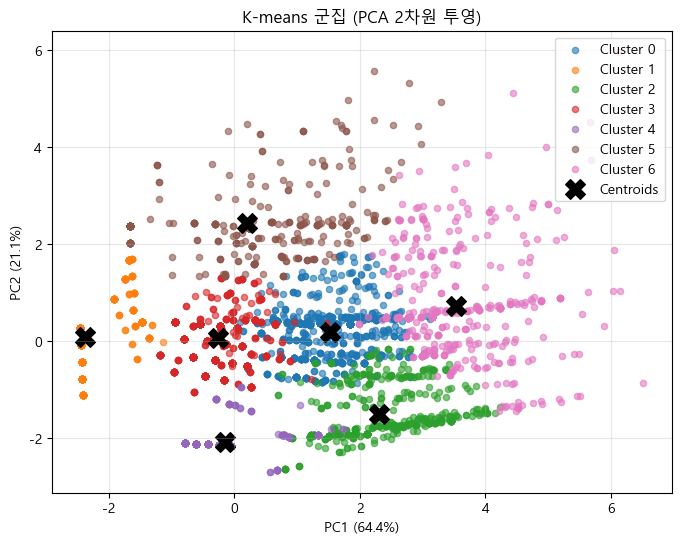

누적 설명력: 85.45 %


In [18]:

# =========================================================
# 9. PCA로 군집 시각화 (해석용 2차원 투영)
# =========================================================
pca_viz = PCA(n_components=2, random_state=42)
X_pca = pca_viz.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': cluster_df['kmeans_cluster'].values
})

plt.figure(figsize=(8, 6))
for c in sorted(plot_df['Cluster'].unique()):
    subset = plot_df[plot_df['Cluster'] == c]
    plt.scatter(subset['PC1'], subset['PC2'], s=20, alpha=0.6, label='Cluster ' + str(c))

centers_pca = pca_viz.transform(km.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X', s=200, label='Centroids')

plt.title('K-means 군집 (PCA 2차원 투영)')
plt.xlabel('PC1 (' + str(round(pca_viz.explained_variance_ratio_[0]*100, 1)) + '%)')
plt.ylabel('PC2 (' + str(round(pca_viz.explained_variance_ratio_[1]*100, 1)) + '%)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('누적 설명력:', round(pca_viz.explained_variance_ratio_.sum() * 100, 2), '%')



## 10. 군집별 프로파일링

- 표본 비중(share_pct)은 **설계가중치 WT를 반영한 모집단 추정 비중**으로 계산한다
  (조사 자체가 인구구조에 맞춰 가중치가 부여된 확률표본이므로, 원자료 그대로 세면
  실제 인구 비중과 다를 수 있음).
- 나머지 특성값(NNI, 채널 이용, 신뢰도 등)은 해석 편의를 위해 비가중 평균을 함께 제시한다.


In [19]:

# =========================================================
# 10. 군집별 특성 요약 (가중 비중 + 비가중 평균)
# =========================================================
summary_cols = [
    'NNI', 'H_norm', 'D_weighted',
    'tier0_freq', 'tier1_freq', 'tier2_freq',
    'Q34_3', 'Q56_2', 'Q87_1', 'trust_curated_avg', 'q93_known'
]

profiled = df[df['kmeans_cluster'] >= 0].copy()  # 뉴스 비활성(-1) 제외

rows = []
for c, g in profiled.groupby('kmeans_cluster'):
    row = {
        'cluster': c,
        'n': len(g),
        # 설계가중치 반영 모집단 추정 비중(%)
        'share_pct_weighted': round(g['WT'].sum() / profiled['WT'].sum() * 100, 1),
        'share_pct_unweighted': round(len(g) / len(profiled) * 100, 1),
        'mean_age': round(g['DQ3'].mean(), 1),
    }
    for col in summary_cols:
        row[col] = round(g[col].mean(), 3)
    rows.append(row)

cluster_summary = pd.DataFrame(rows).set_index('cluster')
print('[군집별 특성 요약 - 전체(가중/비가중 비중 비교)]')
print(cluster_summary)


[군집별 특성 요약 - 전체(가중/비가중 비중 비교)]
            n  share_pct_weighted  share_pct_unweighted  mean_age    NNI  H_norm  D_weighted  tier0_freq  tier1_freq  tier2_freq  Q34_3  Q56_2  Q87_1  trust_curated_avg  q93_known
cluster                                                                                                                                                                            
0         952                18.0                  16.7      48.7  0.486   0.494       0.478       4.373       3.589       3.945  2.740  2.762  3.428              3.090      3.075
1        1639                26.7                  28.8      62.3  0.012   0.022       0.003       4.413       0.029       0.002  2.471  3.000  3.463              2.783      2.652
2         493                10.1                   8.7      37.4  0.597   0.433       0.762       0.606       3.247       5.491  2.490  2.671  3.373              3.073      2.905
3        1337                22.1                  23.5      51.5  0.

In [20]:

# =========================================================
# 11. 인구통계 교차표 (연령 x 성별 x 학력)
# =========================================================
for demo_col in ['age_group', 'gender', 'education']:
    cross_demo = pd.crosstab(profiled['kmeans_cluster'], profiled[demo_col], normalize='index').round(3) * 100
    print('[군집별', demo_col, '분포(%)]')
    print(cross_demo)
    print()


[군집별 age_group 분포(%)]
age_group       20대 이하   30대   40대   50대  60대 이상
kmeans_cluster                                  
0                 10.6  17.3  24.3  25.0    22.8
1                  3.1   6.0   9.0  17.8    64.0
2                 36.9  28.2  16.0  12.0     6.9
3                  9.0  13.2  21.8  24.3    31.6
4                 39.4  24.5  16.2  10.8     9.0
5                  3.3   8.0  18.7  27.0    43.0
6                 16.6  20.7  24.7  21.1    16.8

[군집별 gender 분포(%)]
gender            남성    여성
kmeans_cluster            
0               51.1  48.9
1               42.1  57.9
2               54.8  45.2
3               47.4  52.6
4               47.5  52.5
5               79.3  20.7
6               58.0  42.0

[군집별 education 분포(%)]
education         고졸  대재 이상  중졸 이하
kmeans_cluster                    
0               38.0   59.3    2.6
1               44.5   21.2   34.2
2               21.5   78.1    0.4
3               46.2   47.6    6.1
4               26.4   72.5    1.1
5     

In [21]:

# =========================================================
# 12. 청년층(20대 이하)만 따로 보기
# =========================================================
young = profiled[profiled['age_group'] == '20대 이하'].copy()

rows_y = []
for c, g in young.groupby('kmeans_cluster'):
    row = {'cluster': c, 'n': len(g),
           'share_pct_weighted': round(g['WT'].sum() / young['WT'].sum() * 100, 1) if young['WT'].sum() > 0 else np.nan}
    for col in summary_cols:
        row[col] = round(g[col].mean(), 3)
    rows_y.append(row)

young_summary = pd.DataFrame(rows_y).set_index('cluster')
print('[군집별 특성 요약 - 20대 이하]')
print(young_summary)


[군집별 특성 요약 - 20대 이하]
           n  share_pct_weighted    NNI  H_norm  D_weighted  tier0_freq  tier1_freq  tier2_freq  Q34_3  Q56_2  Q87_1  trust_curated_avg  q93_known
cluster                                                                                                                                           
0        101                13.8  0.499   0.490       0.508       3.644       3.762       3.950  2.606  2.736  3.505              3.168      3.208
1         51                 6.5  0.011   0.019       0.004       3.588       0.039       0.000  3.500    NaN  3.392              2.922      3.600
2        182                28.3  0.593   0.425       0.762       0.511       3.390       5.357  2.424  2.579  3.368              3.104      2.874
3        120                16.2  0.280   0.304       0.257       3.483       3.408       0.092  2.617  3.000  3.425              2.969      3.117
4        175                23.7  0.287   0.044       0.529       0.034       3.497       0.257  


## 13. 자기보고 주 이용경로(Q84)와의 일치도 검증

여기서 처음으로 Q84를 사용한다. 목적은 "NNI/군집이 실제 자기보고와 그럴듯하게 맞물리는가"를
확인하는 것이지, NNI 계산에 다시 투입하는 것이 아니다. Q84의 9998(모름/무응답)은
결측으로 명확히 분리해서 처리한다 (이 부분이 데모 코드의 버그였던 지점).


In [22]:

# =========================================================
# 13. Q84 처리 + 군집별 교차표 (검증용)
# =========================================================
q84_map = {
    1: '종이신문', 2: '텔레비전', 3: '라디오', 4: '잡지', 5: '인터넷 포털/검색엔진',
    6: '언론사 홈페이지', 7: '언론사 앱', 8: '뉴스 모음 앱', 9: '블로그', 10: '온라인 카페/커뮤니티',
    11: 'SNS', 12: '메신저 서비스', 13: '온라인 동영상 플랫폼', 14: '숏폼',
    15: '생성형 AI 서비스', 16: 'AI 스피커 뉴스 서비스', 17: '뉴스레터',
    18: '지난 1주일 이용 없음',
    # 9998(모름/무응답)은 매핑하지 않고 NaN으로 남겨 결측 처리 -> '최대 tier로 자동 취급'하던 기존 버그 제거
}
df['main_path'] = df['Q84'].map(q84_map)

n_9998 = (df['Q84'] == 9998).sum()
print('Q84 무응답/모름(9998) 인원:', n_9998, '(', round(n_9998/len(df)*100, 1), '%) - 교차표에서 자동 제외(NaN)')

cross_q84 = pd.crosstab(profiled['kmeans_cluster'], df.loc[profiled.index, 'main_path'],
                         normalize='index').round(3) * 100
print()
print('[군집별 Q84 주이용경로 분포(%, 무응답 제외)]')
print(cross_q84)


Q84 무응답/모름(9998) 인원: 261 ( 4.4 %) - 교차표에서 자동 제외(NaN)

[군집별 Q84 주이용경로 분포(%, 무응답 제외)]
main_path       AI 스피커 뉴스 서비스  SNS  뉴스 모음 앱  뉴스레터  라디오  메신저 서비스  블로그  생성형 AI 서비스   숏폼  언론사 앱  언론사 홈페이지  온라인 동영상 플랫폼  온라인 카페/커뮤니티  인터넷 포털/검색엔진  종이신문  텔레비전
kmeans_cluster                                                                                                                                           
0                         0.1  0.6      1.4   0.6  0.2      0.3  0.7         0.1  1.7    0.2       0.5          9.1          2.1         38.8   0.3  43.2
1                         0.2  0.0      0.4   0.3  0.7      0.0  0.1         0.0  0.0    0.0       0.0          0.0          1.0          1.0   1.1  95.2
2                         0.2  6.1      1.8   0.4  0.0      2.2  0.0         0.4  6.3    0.6       0.4         17.2          1.6         56.8   0.0   5.9
3                         0.3  0.1      1.0   0.5  0.1      0.0  0.6         0.0  0.1    0.6       0.3          0.6          1.9         40.2   0.


## 14. 군집 이름 붙이기

`optimal_k`는 데이터에 따라 바뀔 수 있으므로, 아래 셀은 **cluster_summary를 보고
직접 채워 넣는 수동 단계**로 남겨둔다. 다만 어떤 변수가 각 군집을 가장 특징짓는지
자동으로 힌트를 뽑아주는 보조 코드를 함께 제공해 작명 부담을 줄인다.


In [23]:

# =========================================================
# 14-1. 군집별 '가장 튀는 변수' 자동 힌트 (z-score 기준)
# =========================================================
feature_for_naming = ['tier0_freq', 'tier1_freq', 'tier2_freq', 'H_norm', 'D_weighted']
z = (cluster_summary[feature_for_naming] - cluster_summary[feature_for_naming].mean()) \
    / cluster_summary[feature_for_naming].std()

print('[군집별 표준화 특성 (절대값이 클수록 그 군집의 특징적인 변수)]')
print(z.round(2))
for c in z.index:
    top_feats = z.loc[c].abs().sort_values(ascending=False).head(2).index.tolist()
    direction = ['높음' if z.loc[c, f] > 0 else '낮음' for f in top_feats]
    print('군집', c, ': 특징 변수 =', list(zip(top_feats, direction)))


[군집별 표준화 특성 (절대값이 클수록 그 군집의 특징적인 변수)]
         tier0_freq  tier1_freq  tier2_freq  H_norm  D_weighted
cluster                                                        
0              0.08        0.44        0.17    0.59        0.27
1              0.09       -2.10       -0.79   -1.35       -1.47
2             -1.08        0.19        0.54    0.34        1.32
3              0.02        0.26       -0.75   -0.22       -0.62
4             -1.24        0.31       -0.74   -1.27        0.42
5              1.78       -0.17       -0.36    0.60       -0.81
6              0.34        1.07        1.95    1.31        0.89
군집 0 : 특징 변수 = [('H_norm', '높음'), ('tier1_freq', '높음')]
군집 1 : 특징 변수 = [('tier1_freq', '낮음'), ('D_weighted', '낮음')]
군집 2 : 특징 변수 = [('D_weighted', '높음'), ('tier0_freq', '낮음')]
군집 3 : 특징 변수 = [('tier2_freq', '낮음'), ('D_weighted', '낮음')]
군집 4 : 특징 변수 = [('H_norm', '낮음'), ('tier0_freq', '낮음')]
군집 5 : 특징 변수 = [('tier0_freq', '높음'), ('D_weighted', '낮음')]
군집 6 : 특징 변수 = [('tier2_freq', '높음

In [24]:

# =========================================================
# 14-2. 군집 이름 매핑 (위 힌트와 cluster_summary를 보고 아래 딕셔너리를 직접 수정할 것)
# =========================================================
# optimal_k에 맞춰 아래 키 개수를 맞춰야 함. 우선 자리표시자(placeholder)로 채워둠.
cluster_name_map = {c: '군집' + str(c) + '_이름을_채우세요' for c in cluster_summary.index}

# 예시(참고용, 실제 결과 보고 수정):
# cluster_name_map = {
#     0: '전통-포털 병행형',
#     1: '저관여 포털 경유형',
#     2: '관계망/영상 확산형',
#     3: 'TV 직접충성형',
#     4: '초분산 탈맥락형',
# }

df['cluster_name'] = df['kmeans_cluster'].map(cluster_name_map)
df.loc[df['kmeans_cluster'] == -1, 'cluster_name'] = '뉴스 비활성형'

print('[군집 이름 분포]')
print((df['cluster_name'].value_counts(normalize=True) * 100).round(1))


[군집 이름 분포]
cluster_name
군집1_이름을_채우세요    27.3
군집3_이름을_채우세요    22.3
군집0_이름을_채우세요    15.9
군집2_이름을_채우세요     8.2
군집6_이름을_채우세요     7.8
군집4_이름을_채우세요     7.4
군집5_이름을_채우세요     6.0
뉴스 비활성형          5.1
Name: proportion, dtype: float64



## 15. 시각화


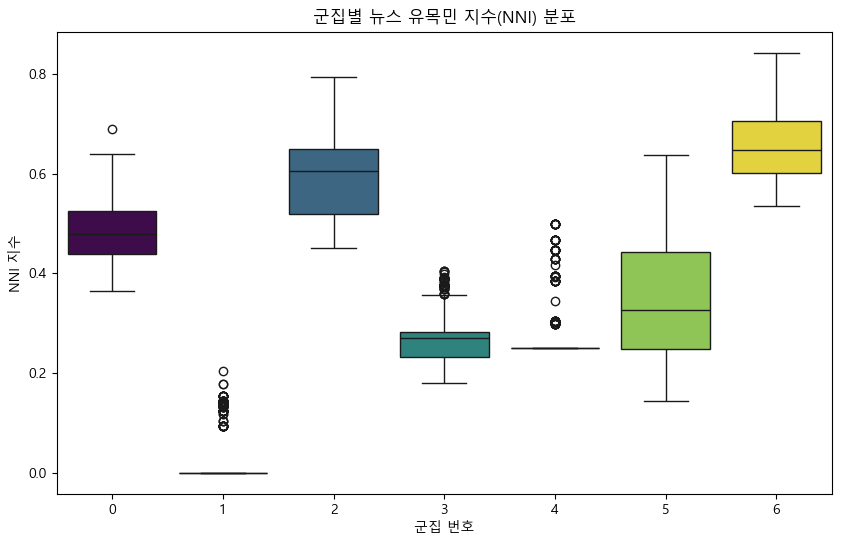

In [25]:

# 1. 군집별 NNI 분포 (박스플롯)
plt.figure(figsize=(10, 6))
sns.boxplot(x='kmeans_cluster', y='NNI', hue='kmeans_cluster', data=profiled, palette='viridis', legend=False)
plt.title('군집별 뉴스 유목민 지수(NNI) 분포')
plt.xlabel('군집 번호')
plt.ylabel('NNI 지수')
plt.show()


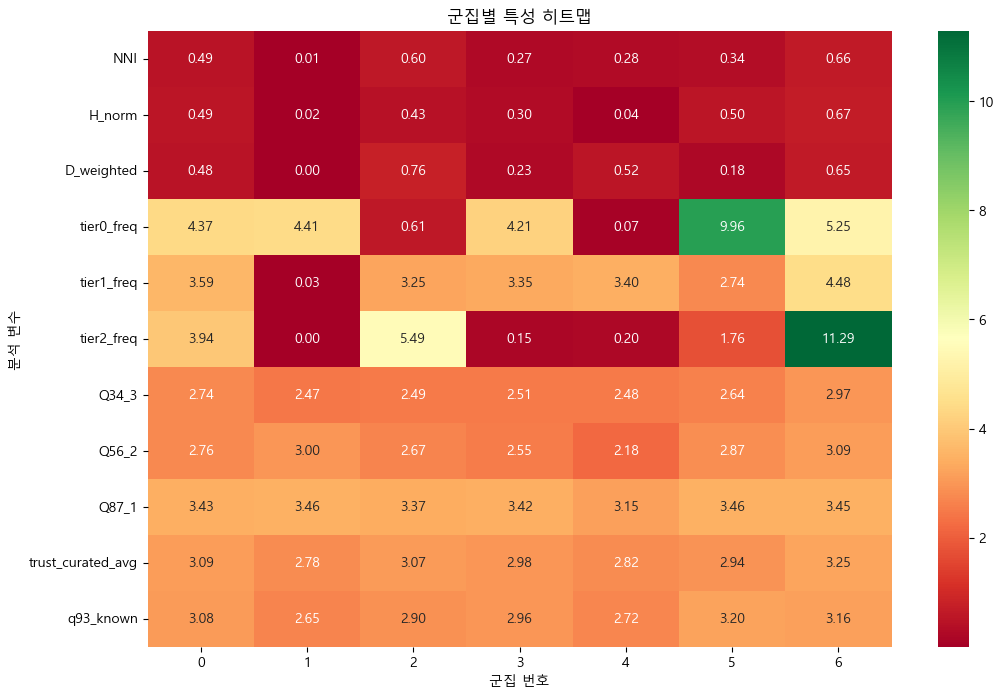

In [26]:

# 2. 군집별 변수 히트맵
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_summary[summary_cols].T, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('군집별 특성 히트맵')
plt.xlabel('군집 번호')
plt.ylabel('분석 변수')
plt.show()


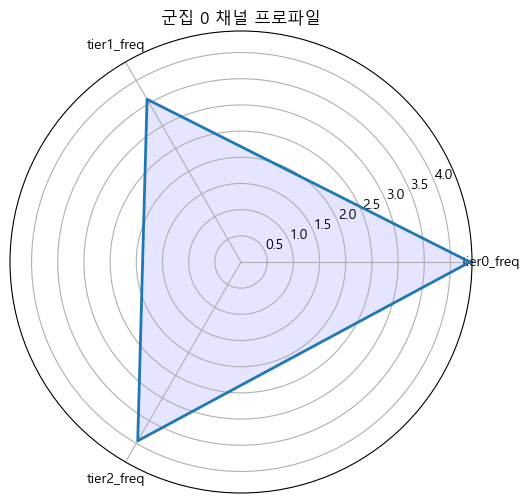

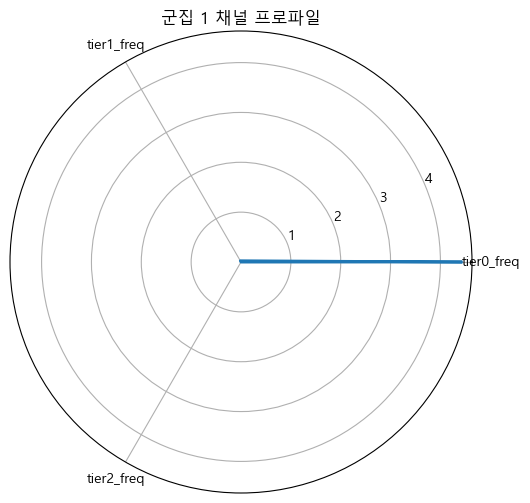

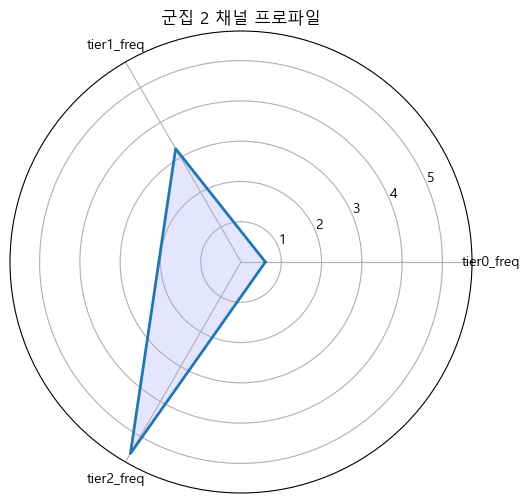

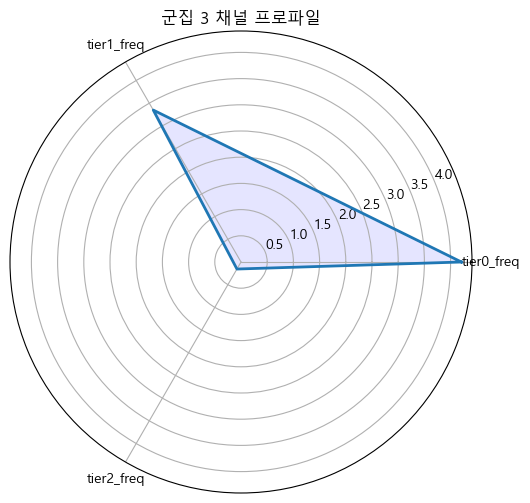

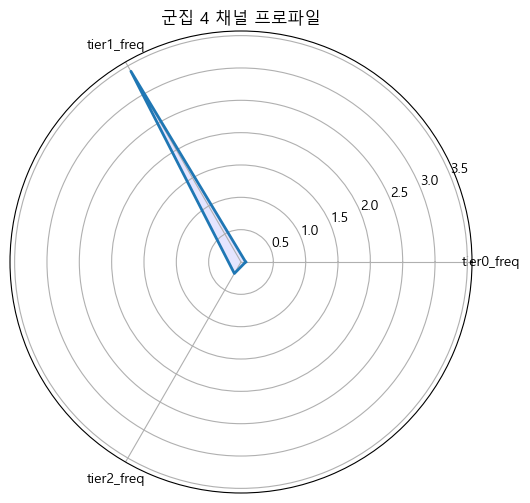

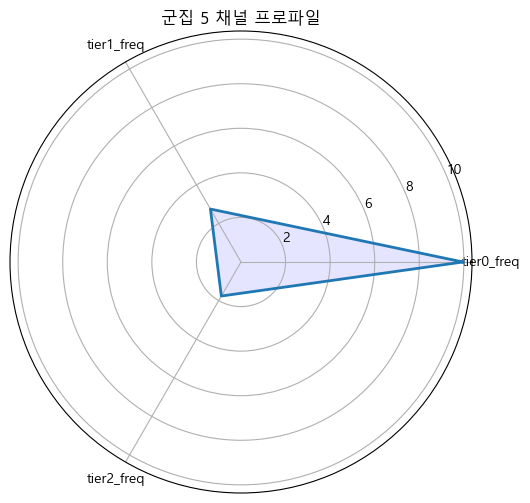

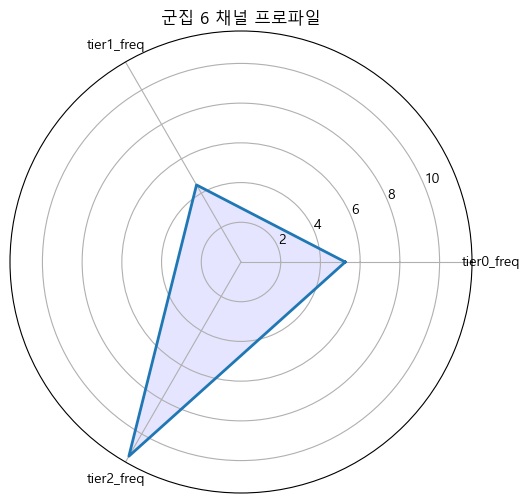

In [27]:

# 3. 레이더 차트 (tier별 채널 이용 프로파일)
def plot_radar(cluster_id, data, features):
    labels = features
    values = data.loc[cluster_id, features].values.flatten().tolist()
    values += values[:1]
    angles = [n / float(len(labels)) * 2 * pi for n in range(len(labels))]
    angles += angles[:1]

    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)
    plt.xticks(angles[:-1], labels)
    ax.plot(angles, values, linewidth=2, linestyle='solid')
    ax.fill(angles, values, 'b', alpha=0.1)
    plt.title('군집 ' + str(cluster_id) + ' 채널 프로파일')
    plt.show()

radar_features = ['tier0_freq', 'tier1_freq', 'tier2_freq']
for c in cluster_summary.index:
    plot_radar(c, cluster_summary, radar_features)


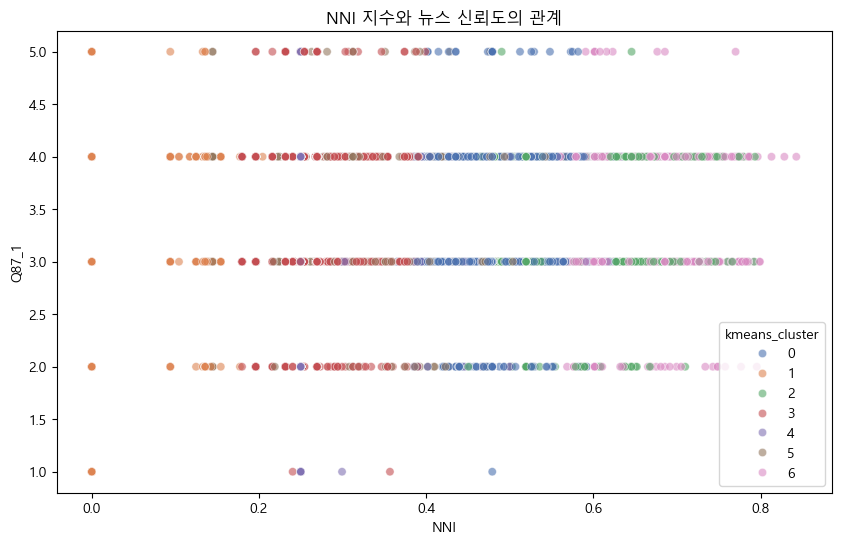

In [28]:

# 4. NNI와 언론 신뢰도(Q87_1)의 관계
plt.figure(figsize=(10, 6))
sns.scatterplot(x='NNI', y='Q87_1', hue='kmeans_cluster', data=profiled, palette='deep', alpha=0.6)
plt.title('NNI 지수와 뉴스 신뢰도의 관계')
plt.show()


In [ ]:

# 5. 뉴스 소비 생태계 지도 (H_norm vs D_weighted)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=profiled, x='H_norm', y='D_weighted', hue='kmeans_cluster', palette='tab10', alpha=0.6)
plt.title('뉴스 소비 생태계 지도 (H_norm vs D_weighted)')
plt.axhline(profiled['D_weighted'].mean(), color='red', linestyle='--')
plt.axvline(profiled['H_norm'].mean(), color='blue', linestyle='--')
plt.show()



## 16. 서비스 활용을 위한 모델 아티팩트 저장 + 실시간 채점 함수

공모전에서 "서비스로 어떻게 쓸 것인가"를 보여주려면, 학습된 전처리기/모델을
**신규 이용자 응답 몇 개만으로 즉시 점수를 매기는 함수**로 감싸두는 것이 중요하다.

- `scaler`, `km`(KMeans), `alpha`/`beta`, `channel_specs`, `H_max`, NNI 참조 분포를
  하나의 아티팩트 묶음으로 저장.
- 실제 서비스에서는 사용자에게 11개 채널을 전부 묻기보다, 앱 내 설문을 6~8문항 정도로 줄이고
  나머지는 0으로 간주하는 식으로 UX를 단순화할 수 있음 (아래 함수는 일부 채널만 입력해도 동작).


In [ ]:

# =========================================================
# 16-1. 아티팩트 저장
# =========================================================
ARTIFACT_DIR = 'nni_service_artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

artifacts = {
    'scaler': scaler,                       # 군집화용 StandardScaler (6개 피처 기준)
    'kmeans': km,                           # 최종 KMeans 모델
    'cluster_features': cluster_features,   # 군집화에 사용한 피처 순서
    'channel_specs': channel_specs,          # 채널 -> 문항/티어 매핑
    'H_max': H_max,
    'alpha': alpha,
    'beta': beta,
    'nni_reference_sorted': np.sort(df['NNI'].dropna().values),  # 백분위 계산용 참조 분포
    'cluster_name_map': cluster_name_map,
}
joblib.dump(artifacts, os.path.join(ARTIFACT_DIR, 'nni_artifacts.joblib'))
print('모델 아티팩트를', os.path.join(ARTIFACT_DIR, 'nni_artifacts.joblib'), '에 저장했습니다.')


In [ ]:

# =========================================================
# 16-2. 신규 이용자 실시간 채점 함수
# =========================================================
# channel_days 형식: {channel_specs의 key: 최근 1주일 평일 이용일수(0~5)}
# 일부 채널을 생략하면 자동으로 0(이용 안 함)으로 간주한다.
# 예) {'sns': 5, 'video': 4, 'portal': 2}
# 반환값: NNI 점수, 백분위, 군집 번호/이름, 채널별 tier 구성비를 담은 dict.

def score_new_user(channel_days, artifacts=artifacts):
    specs = artifacts['channel_specs']
    tiers = np.array([spec['tier'] for spec in specs.values()], dtype=float)
    keys = list(specs.keys())

    freq = np.array([float(channel_days.get(k, 0)) for k in keys])
    total = freq.sum()

    if total <= 0:
        return {
            'status': 'news_inactive',
            'message': '최근 1주일간 확인된 뉴스 채널 이용이 없어 지수를 계산할 수 없습니다.'
        }

    # H_norm
    p = freq[freq > 0] / total
    H = -(p * np.log2(p)).sum()
    H_norm = H / artifacts['H_max']

    # D_weighted
    D_weighted = (freq * tiers).sum() / total / 2.0

    # NNI
    nni = artifacts['alpha'] * H_norm + artifacts['beta'] * D_weighted

    # 백분위 (참조 분포 내 위치)
    ref = artifacts['nni_reference_sorted']
    percentile = float(np.searchsorted(ref, nni) / len(ref) * 100)

    # tier별 이용량 (군집화 피처와 동일한 방식으로 구성)
    tier0 = freq[tiers == 0].sum()
    tier1 = freq[tiers == 1].sum()
    tier2 = freq[tiers == 2].sum()

    feat_row = pd.DataFrame([[H_norm, D_weighted, nni, tier0, tier1, tier2]],
                             columns=artifacts['cluster_features'])
    X_new = artifacts['scaler'].transform(feat_row)
    cluster_id = int(artifacts['kmeans'].predict(X_new)[0])
    cluster_name = artifacts['cluster_name_map'].get(cluster_id, '군집' + str(cluster_id))

    return {
        'status': 'ok',
        'NNI': round(float(nni), 4),
        'NNI_percentile': round(percentile, 1),
        'H_norm': round(float(H_norm), 4),
        'D_weighted': round(float(D_weighted), 4),
        'cluster_id': cluster_id,
        'cluster_name': cluster_name,
        'tier0_freq': float(tier0), 'tier1_freq': float(tier1), 'tier2_freq': float(tier2),
    }


# 사용 예시: 유튜브/SNS 위주로 뉴스를 보는 가상의 20대 이용자
example_result = score_new_user({'sns': 5, 'video': 5, 'shortform': 3, 'portal': 1})
print('예시 이용자 채점 결과:')
for k, v in example_result.items():
    print(' ', k, ':', v)



## 17. 요약 및 다음 단계

- **지표 측면**: NNI를 단일 문항(Q84) 의존에서 전체 채널 이용 패턴 기반으로 재정의하고,
  가중치를 데이터로 추정 + 구성 타당도까지 확인함으로써 "왜 이 숫자가 의미 있는가"에
  답할 수 있는 근거를 갖춤.
- **서비스 측면**: 학습된 전처리기/모델을 저장하고, 몇 개 문항만으로 즉시 채점하는 함수를
  제공해 실제 웹/앱 서비스 백엔드로 바로 확장 가능한 구조를 마련함.
- **남은 수동 작업**: 14절의 `cluster_name_map`을 실제 `cluster_summary` 결과를 보고 채우고,
  본 문서에서 잠정적으로 정한 tier 구간(예: 팟캐스트=1)이 서비스 스토리에 맞는지 재검토할 것.
